# **Bagian 1 - EDA**

## Import Library

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

## Load Dataset

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
import os
folder_path = '/content/drive/MyDrive/bengkod/UAS'
print(os.listdir(folder_path))

['Sales - Marketing customer dataset.csv', 'UAS BENGKOD']


In [26]:
df = pd.read_csv('/content/drive/MyDrive/bengkod/UAS/Sales - Marketing customer dataset.csv')

print(f"✅ Dataset berhasil dimuat!")
print(f"   Jumlah baris : {df.shape[0]:,}")
print(f"   Jumlah kolom : {df.shape[1]}")

✅ Dataset berhasil dimuat!
   Jumlah baris : 15,000
   Jumlah kolom : 30


## Head, Info, Describe

In [27]:
# 5 baris pertama
print("\n📌 5 Baris Pertama:")
display(df.head())


📌 5 Baris Pertama:


,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,coupon_code,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,1,7,13.903745,5.415164,0.67,0.26,559.524958,65.246704,0,NEW20,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,0,19,5.112528,5.352441,0.70,0.37,356.491344,48.473887,1,NEW20,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,1,18,9.742749,3.594719,0.47,0.44,689.332196,77.815371,0,NaN,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,1,16,9.642654,2.949531,0.58,0.37,445.429636,71.712192,0,NaN,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,0,12,7.791291,2.405539,0.05,0.16,686.286022,44.990246,1,NaN,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


In [28]:
# Info dataset
print("\n📌 Informasi Dataset:")
df.info()


📌 Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages_per

In [29]:
# Statistik deskriptif
print("\n📌 Statistik Deskriptif:")
display(df.describe(include='all').T)


📌 Statistik Deskriptif:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,15000.0,NaN,NaN,NaN,17500.5,4330.271354,10001.0,13750.75,17500.5,21250.25,25000.0
gender,14262,3,Male,6844,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,13800.0,NaN,NaN,NaN,35.203913,10.334384,-4.0,28.0,35.0,42.0,95.0
country,15000,5,Germany,3072,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,15000,7,London,2236,NaN,NaN,NaN,NaN,NaN,NaN,NaN
signup_date,15000,1000,2024-09-20 00:00:00,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last_purchase_date,15000,800,2025-01-17 00:00:00,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
acquisition_channel,15000,5,Organic,3055,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device_type,15000,3,Tablet,5043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subscription_type,15000,2,Monthly,7666,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Cek Missing Value

In [30]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': round(missing_pct, 2)
}).sort_values('Persentase (%)', ascending=False)

display(missing_df[missing_df['Jumlah Missing'] > 0])

,Jumlah Missing,Persentase (%)
coupon_code,6133,40.89
age,1200,8.00
total_spent,1050,7.00
gender,738,4.92
satisfaction_score,702,4.68


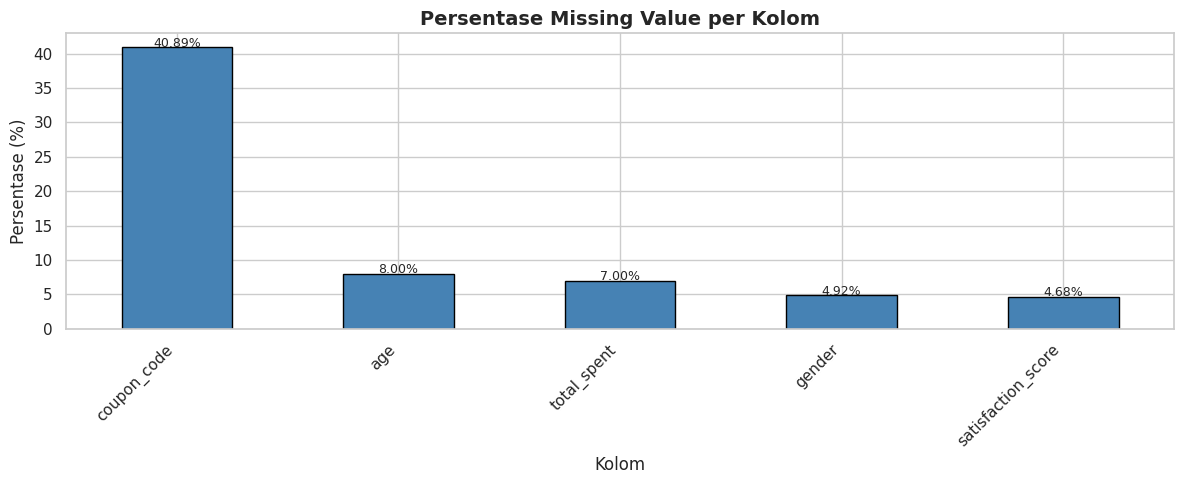

In [31]:
# Visualisasi
cols_missing = missing_pct[missing_pct > 0]

if len(cols_missing) > 0:
    plt.figure(figsize=(12, 5))
    cols_missing.sort_values(ascending=False).plot(
        kind='bar', color='steelblue', edgecolor='black'
    )
    plt.title('Persentase Missing Value per Kolom', fontsize=14, fontweight='bold')
    plt.xlabel('Kolom')
    plt.ylabel('Persentase (%)')
    plt.xticks(rotation=45, ha='right')
    for i, v in enumerate(cols_missing.sort_values(ascending=False)):
        plt.text(i, v + 0.05, f'{v:.2f}%', ha='center', fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("\n✅ Tidak ada missing value dalam dataset!")

## Distribusi Target Churn

In [32]:
# Hitung distribusi
churn_counts = df['churn'].value_counts()
churn_pct    = df['churn'].value_counts(normalize=True) * 100

print(f"\n  Tidak Churn (0) : {churn_counts[0]:,} data ({churn_pct[0]:.2f}%)")
print(f"  Churn       (1) : {churn_counts[1]:,} data ({churn_pct[1]:.2f}%)")
print(f"  Total           : {len(df):,} data")

# Rasio imbalance
rasio = churn_counts[0] / churn_counts[1]
print(f"\n  Rasio 0:1       : {rasio:.2f}:1")

# Kesimpulan otomatis
if 0.8 <= churn_pct[1]/100 <= 1.2 or abs(churn_pct[0] - churn_pct[1]) < 20:
    status = "✅ BALANCED — distribusi kelas cukup seimbang"
    rekomendasi = "Tidak perlu teknik resampling khusus (SMOTE, dll)"
else:
    status = "⚠️  IMBALANCED — distribusi kelas tidak seimbang"
    rekomendasi = "Pertimbangkan teknik resampling seperti SMOTE atau class_weight='balanced'"

print(f"\n  Status    : {status}")
print(f"  Rekomendasi : {rekomendasi}")


  Tidak Churn (0) : 12,702 data (84.68%)
  Churn       (1) : 2,298 data (15.32%)
  Total           : 15,000 data

  Rasio 0:1       : 5.53:1

  Status    : ⚠️  IMBALANCED — distribusi kelas tidak seimbang
  Rekomendasi : Pertimbangkan teknik resampling seperti SMOTE atau class_weight='balanced'


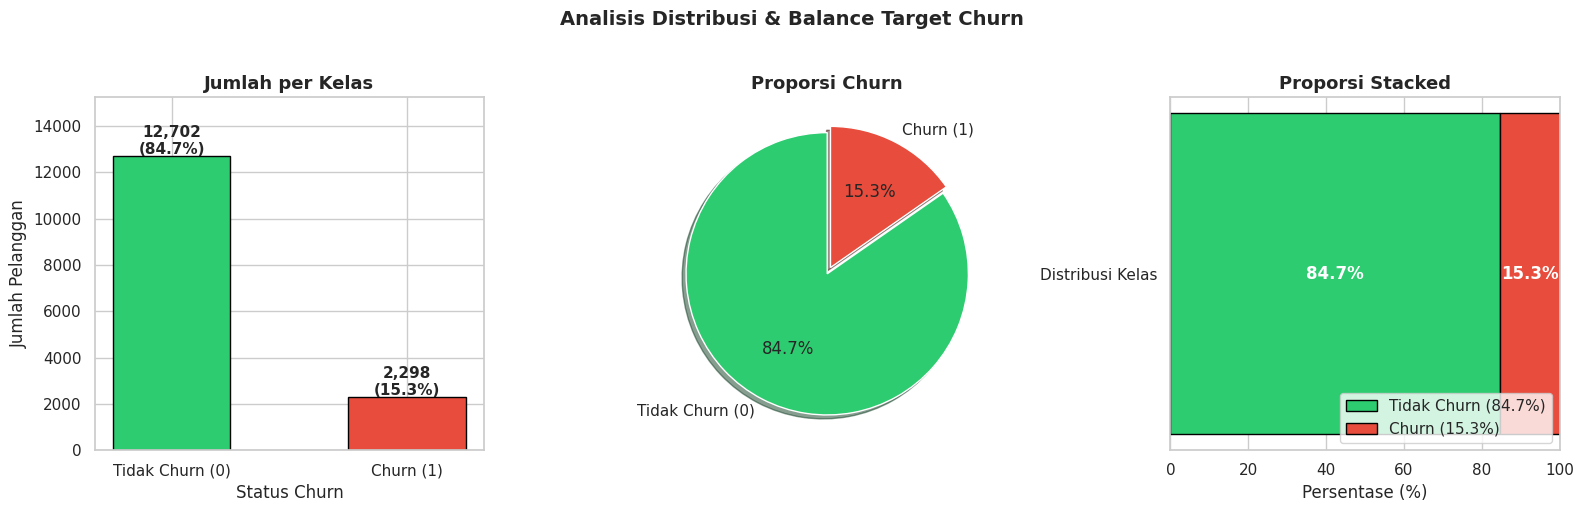

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Bar Chart
bars = axes[0].bar(
    ['Tidak Churn (0)', 'Churn (1)'],
    churn_counts.values,
    color=['#2ecc71', '#e74c3c'],
    edgecolor='black', width=0.5
)
axes[0].set_title('Jumlah per Kelas', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Status Churn')
axes[0].set_ylabel('Jumlah Pelanggan')
for bar, val, pct in zip(bars, churn_counts.values, churn_pct.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 80,
        f'{val:,}\n({pct:.1f}%)',
        ha='center', fontweight='bold', fontsize=11
    )
axes[0].set_ylim(0, max(churn_counts.values) * 1.2)

# 2. Pie Chart
axes[1].pie(
    churn_counts.values,
    labels=['Tidak Churn (0)', 'Churn (1)'],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90,
    explode=(0, 0.05),
    shadow=True
)
axes[1].set_title('Proporsi Churn', fontsize=13, fontweight='bold')

# 3. Horizontal Bar (untuk lihat rasio lebih jelas)
axes[2].barh(
    ['Distribusi Kelas'],
    [churn_pct[0]],
    color='#2ecc71', edgecolor='black', label=f'Tidak Churn ({churn_pct[0]:.1f}%)'
)
axes[2].barh(
    ['Distribusi Kelas'],
    [churn_pct[1]],
    left=[churn_pct[0]],
    color='#e74c3c', edgecolor='black', label=f'Churn ({churn_pct[1]:.1f}%)'
)
axes[2].set_xlim(0, 100)
axes[2].set_title('Proporsi Stacked', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Persentase (%)')
axes[2].legend(loc='lower right')
axes[2].text(churn_pct[0]/2, 0, f"{churn_pct[0]:.1f}%", ha='center', va='center',
             fontweight='bold', color='white', fontsize=12)
axes[2].text(churn_pct[0] + churn_pct[1]/2, 0, f"{churn_pct[1]:.1f}%", ha='center',
             va='center', fontweight='bold', color='white', fontsize=12)

plt.suptitle('Analisis Distribusi & Balance Target Churn', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Heatmap Korelasi

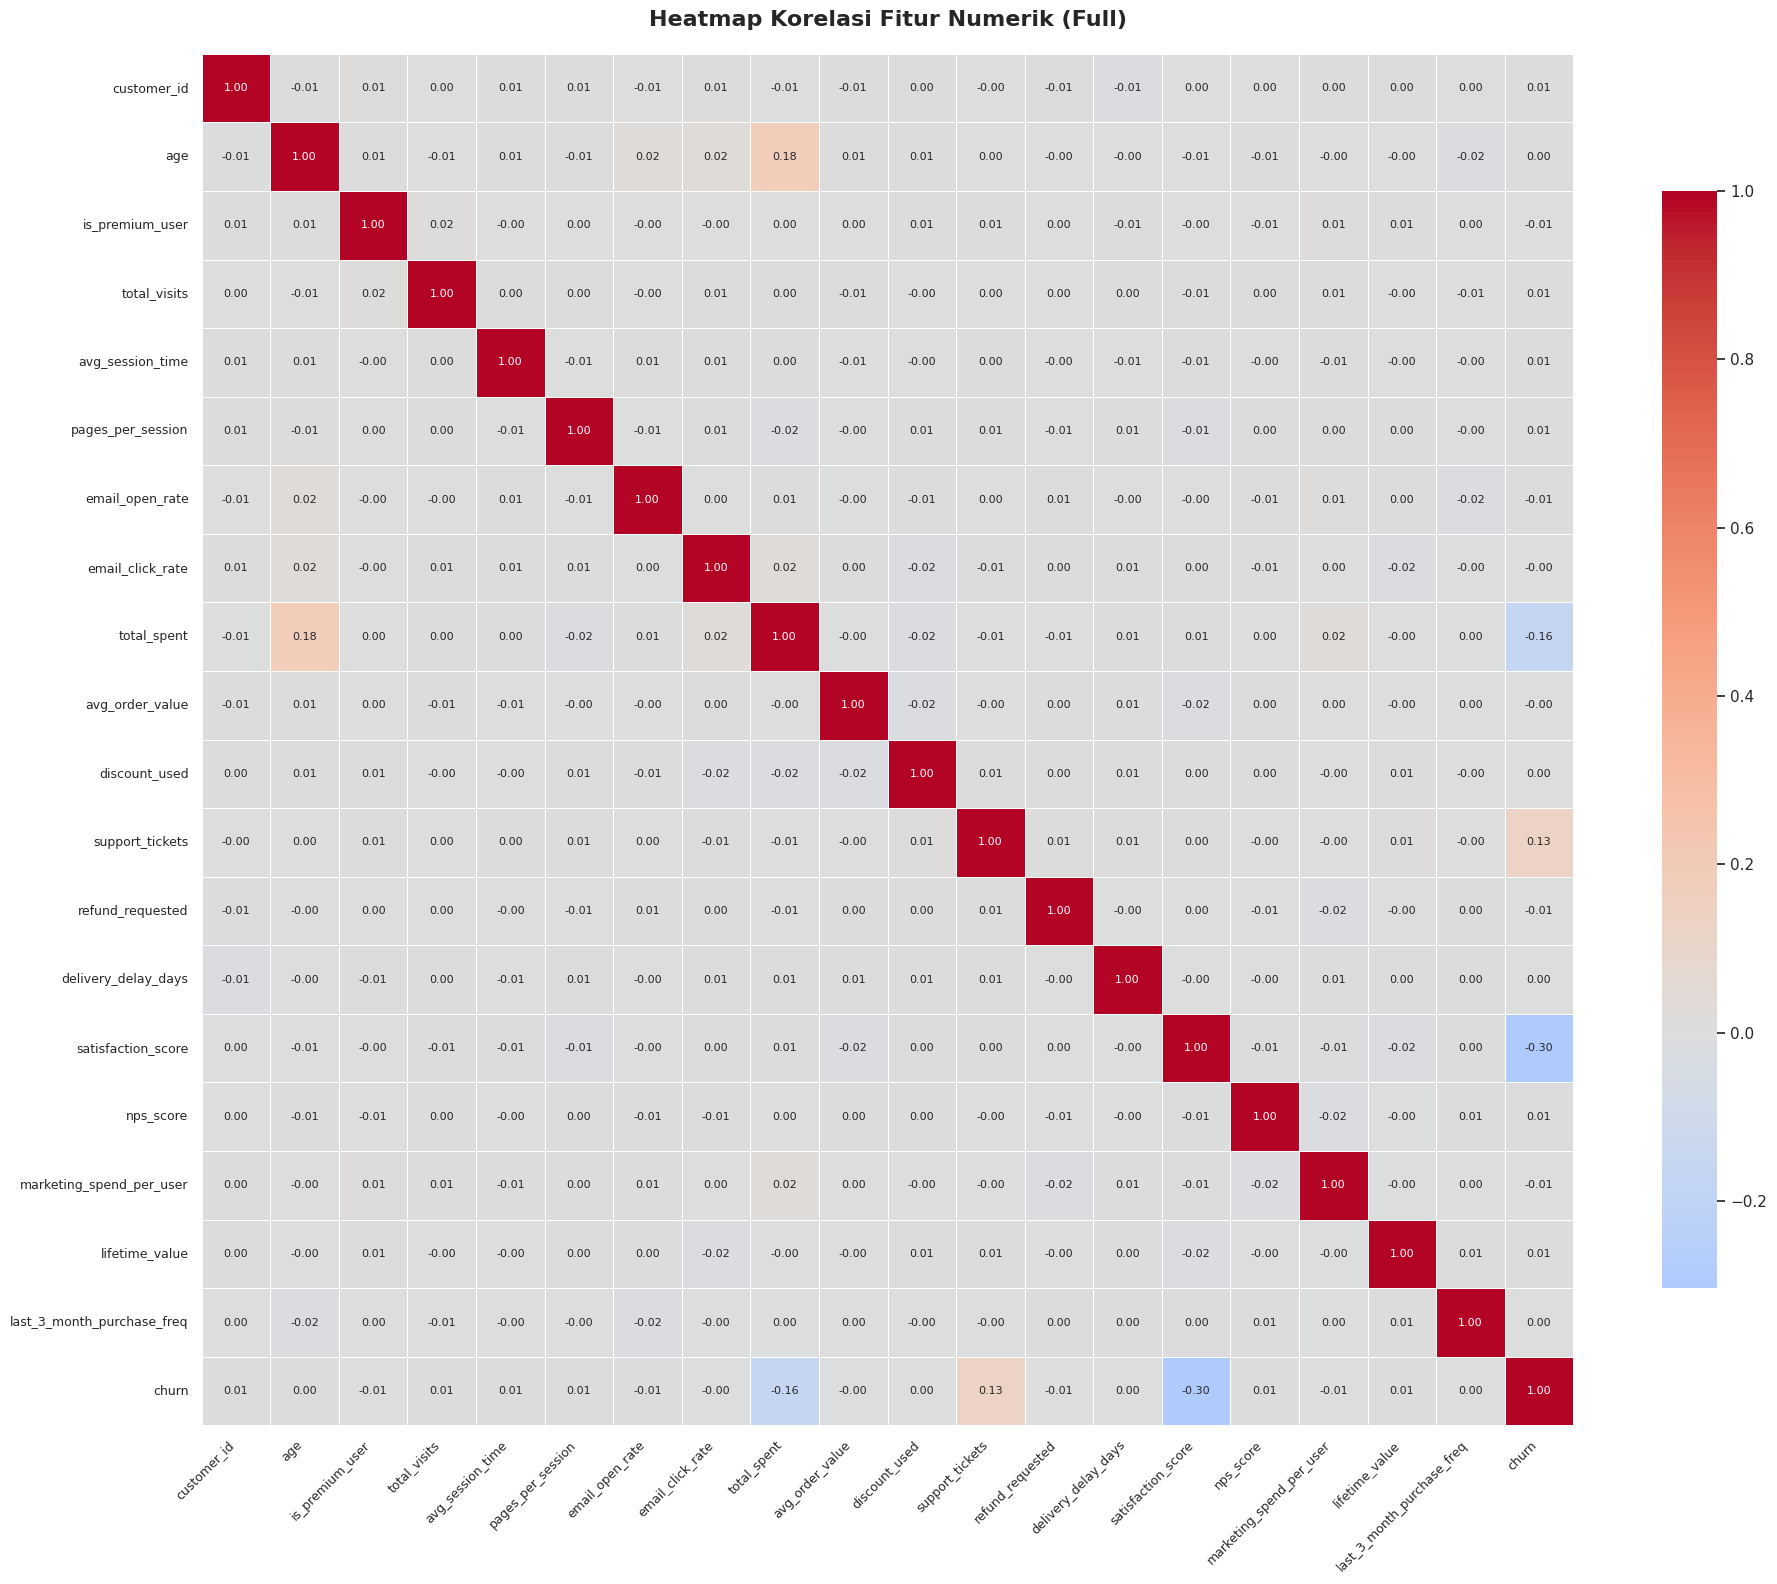

In [34]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
corr_matrix  = df[numeric_cols].corr()

plt.figure(figsize=(20, 16))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'shrink': 0.8},
    annot_kws={'size': 8}
)
plt.title('Heatmap Korelasi Fitur Numerik (Full)', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()


📌 Korelasi Fitur terhadap 'churn' (diurutkan):


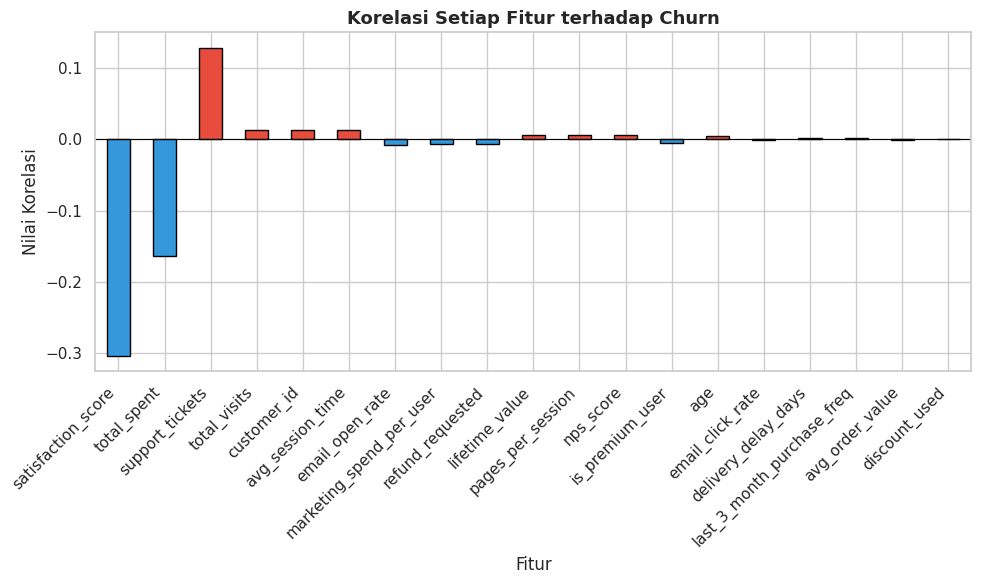

,Korelasi dengan Churn
satisfaction_score,-0.303588
total_spent,-0.163279
support_tickets,0.127910
total_visits,0.013212
customer_id,0.012208
avg_session_time,0.012198
email_open_rate,-0.008439
marketing_spend_per_user,-0.007315
refund_requested,-0.006959
lifetime_value,0.006250


In [35]:
print("\n📌 Korelasi Fitur terhadap 'churn' (diurutkan):")
churn_corr = corr_matrix['churn'].drop('churn').sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in churn_corr.values]
churn_corr.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Korelasi Setiap Fitur terhadap Churn', fontsize=13, fontweight='bold')
plt.xlabel('Fitur')
plt.ylabel('Nilai Korelasi')
plt.axhline(y=0, color='black', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

display(churn_corr.to_frame().rename(columns={'churn': 'Korelasi dengan Churn'}))

#**Bagian 2 - Direct Modeling**

Melatih model secara langsung tanpa preprocessing dan tanpa hyperparameter tuning

## Persiapan Fitur & Target

In [36]:
# Drop kolom non-numerik dulu untuk direct modeling
# (karena tanpa preprocessing, model tidak bisa baca object)
cols_to_drop = ['customer_id', 'signup_date', 'last_purchase_date',
                'gender', 'country', 'city', 'acquisition_channel',
                'device_type', 'subscription_type', 'coupon_code',
                'payment_method']

df_direct = df.drop(columns=cols_to_drop)

# Drop baris yang ada missing value (karena tanpa preprocessing)
df_direct = df_direct.dropna()

print(f"Shape setelah drop kolom non-numerik & missing: {df_direct.shape}")

# Tetapkan X dan y
X = df_direct.drop(columns=['churn'])
y = df_direct['churn']

print(f"\nFitur prediktor (X) : {X.shape[1]} kolom")
print(f"Variabel target (y) : {y.shape[0]:,} baris")
print(f"\nKolom X yang digunakan:")
print(list(X.columns))

Shape setelah drop kolom non-numerik & missing: (12246, 19)

Fitur prediktor (X) : 18 kolom
Variabel target (y) : 12,246 baris

Kolom X yang digunakan:
['age', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq']


##Train Test Split

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # pastikan proporsi churn seimbang di train & test
)

print(f"\n  Total data    : {len(X):,}")
print(f"  Data latih    : {len(X_train):,} ({len(X_train)/len(X)*100:.0f}%)")
print(f"  Data uji      : {len(X_test):,}  ({len(X_test)/len(X)*100:.0f}%)")
print(f"\n  Distribusi y_train:")
print(y_train.value_counts().to_string())
print(f"\n  Distribusi y_test:")
print(y_test.value_counts().to_string())


  Total data    : 12,246
  Data latih    : 9,796 (80%)
  Data uji      : 2,450  (20%)

  Distribusi y_train:
churn
0    8241
1    1555

  Distribusi y_test:
churn
0    2061
1     389


## Definisi 3 Model

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# 1. Model Konvensional → Logistic Regression
model_lr = LogisticRegression(random_state=42, max_iter=1000)

# 2. Model Ensemble Bagging → Random Forest
model_rf = RandomForestClassifier(random_state=42)

# 3. Model Ensemble Voting → LR + SVM + KNN
estimators = [
    ('lr',  LogisticRegression(random_state=42, max_iter=1000)),
    ('svm', SVC(probability=True, random_state=42)),
    ('knn', KNeighborsClassifier())
]
model_voting = VotingClassifier(estimators=estimators, voting='soft')

models = {
    'Logistic Regression (Konvensional)' : model_lr,
    'Random Forest (Ensemble Bagging)'   : model_rf,
    'Voting Classifier (LR + SVM + KNN)' : model_voting
}

print("\n✅ Model yang akan dilatih:")
for i, name in enumerate(models.keys(), 1):
    print(f"   {i}. {name}")


✅ Model yang akan dilatih:
   1. Logistic Regression (Konvensional)
   2. Random Forest (Ensemble Bagging)
   3. Voting Classifier (LR + SVM + KNN)


##Training & Evaluasi Semua Model

In [39]:
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              confusion_matrix, classification_report)
import time

results = {}

for name, model in models.items():
    print(f"\n⏳ Melatih: {name}...")

    # Training
    start = time.time()
    model.fit(X_train, y_train)
    duration = time.time() - start

    # Prediksi
    y_pred = model.predict(X_test)

    # Metrik
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)

    results[name] = {
        'Accuracy' : acc,
        'Precision': prec,
        'Recall'   : rec,
        'F1-Score' : f1,
        'Waktu (s)': round(duration, 2)
    }

    print(f"   ✅ Selesai dalam {duration:.2f} detik")
    print(f"   Accuracy : {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")


⏳ Melatih: Logistic Regression (Konvensional)...
   ✅ Selesai dalam 3.63 detik
   Accuracy : 0.8437 | Precision: 0.5278 | Recall: 0.1465 | F1: 0.2294

⏳ Melatih: Random Forest (Ensemble Bagging)...
   ✅ Selesai dalam 2.68 detik
   Accuracy : 0.8376 | Precision: 0.4863 | Recall: 0.4113 | F1: 0.4457

⏳ Melatih: Voting Classifier (LR + SVM + KNN)...
   ✅ Selesai dalam 17.26 detik
   Accuracy : 0.8453 | Precision: 0.6562 | Recall: 0.0540 | F1: 0.0998


##Tabel Perbandingan Hasil

,Accuracy,Precision,Recall,F1-Score,Waktu (s)
Random Forest (Ensemble Bagging),0.8376,0.4863,0.4113,0.4457,2.680000
Logistic Regression (Konvensional),0.8437,0.5278,0.1465,0.2294,3.630000
Voting Classifier (LR + SVM + KNN),0.8453,0.6562,0.0540,0.0998,17.260000


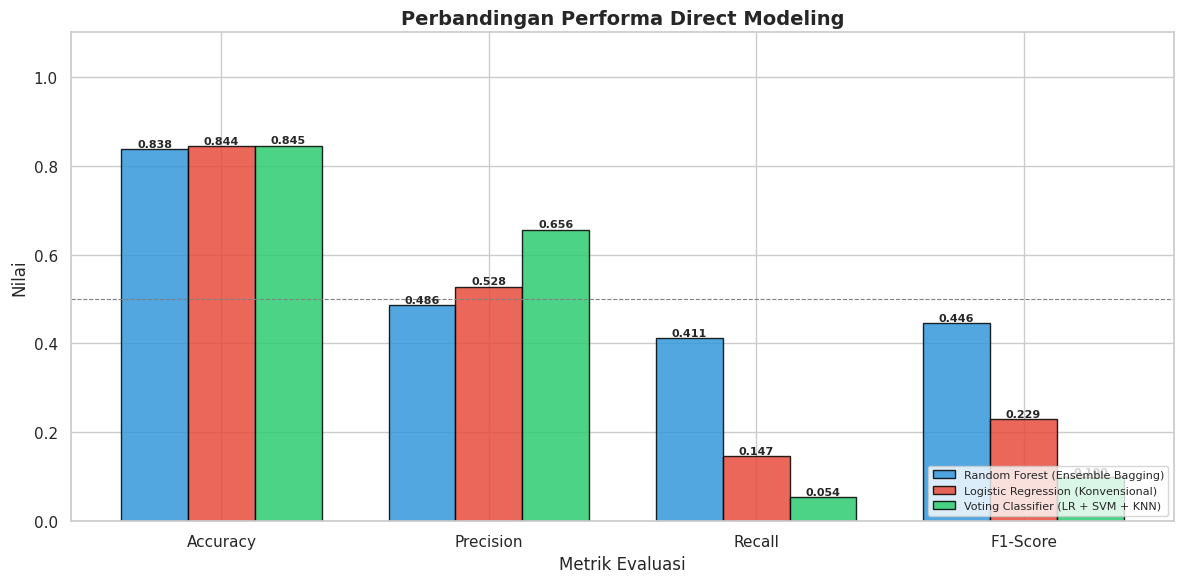

In [40]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('F1-Score', ascending=False)

display(results_df.style
        .format({'Accuracy':'{:.4f}', 'Precision':'{:.4f}',
                 'Recall':'{:.4f}', 'F1-Score':'{:.4f}'})
        .background_gradient(subset=['Accuracy','Precision','Recall','F1-Score'],
                             cmap='Greens')
        .set_caption("Perbandingan Performa Direct Modeling"))

# Visualisasi bar chart perbandingan
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.25
colors = ['#3498db', '#e74c3c', '#2ecc71']

fig, ax = plt.subplots(figsize=(12, 6))
for i, (name, row) in enumerate(results_df.iterrows()):
    vals = [row[m] for m in metrics]
    bars = ax.bar(x + i*width, vals, width, label=name, color=colors[i],
                  edgecolor='black', alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')

ax.set_xlabel('Metrik Evaluasi')
ax.set_ylabel('Nilai')
ax.set_title('Perbandingan Performa Direct Modeling', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.legend(loc='lower right', fontsize=8)
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.8, label='Baseline 0.5')
plt.tight_layout()
plt.show()

## Confusion Matrix Semua Model

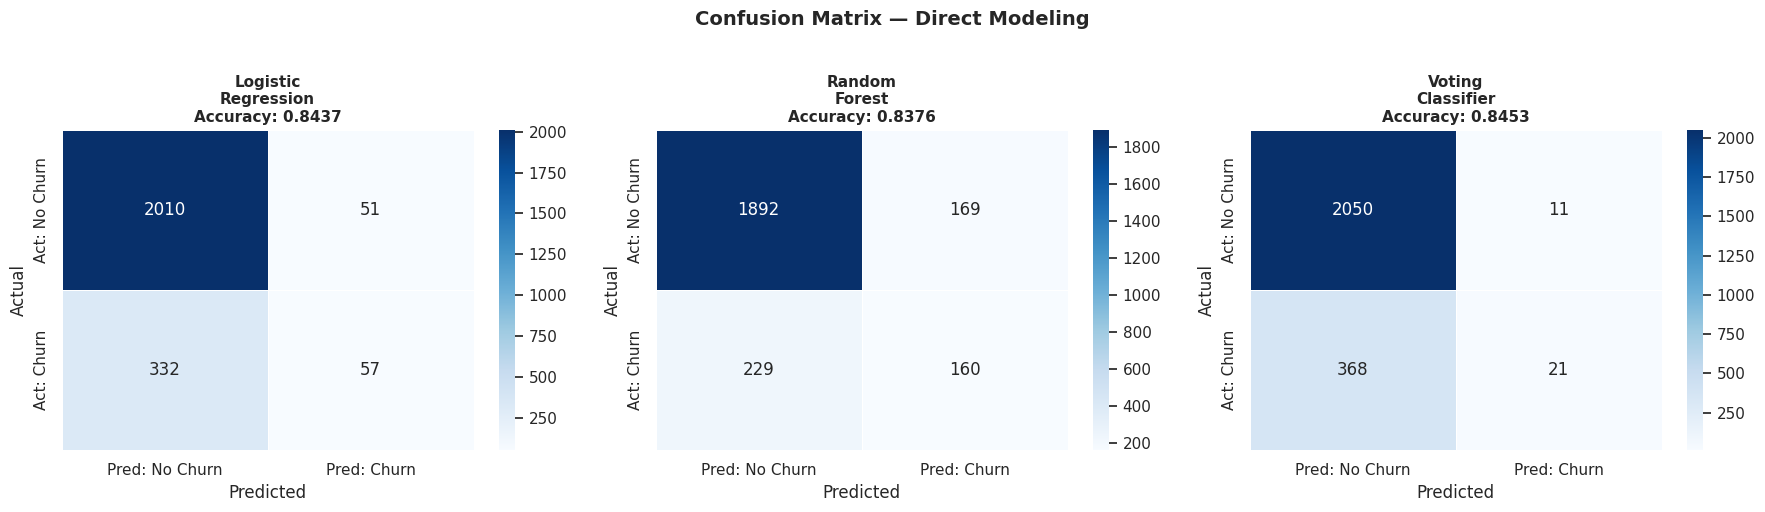

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
short_names = ['Logistic\nRegression', 'Random\nForest', 'Voting\nClassifier']

for ax, (name, model), short in zip(axes, models.items(), short_names):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Pred: No Churn', 'Pred: Churn'],
        yticklabels=['Act: No Churn', 'Act: Churn'],
        ax=ax, linewidths=0.5
    )
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f'{short}\nAccuracy: {acc:.4f}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrix — Direct Modeling', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Classification Report Detail

In [42]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n{'─'*50}")
    print(f"📌 {name}")
    print(f"{'─'*50}")
    print(classification_report(y_test, y_pred,
          target_names=['Tidak Churn (0)', 'Churn (1)']))


──────────────────────────────────────────────────
📌 Logistic Regression (Konvensional)
──────────────────────────────────────────────────
                 precision    recall  f1-score   support

Tidak Churn (0)       0.86      0.98      0.91      2061
      Churn (1)       0.53      0.15      0.23       389

       accuracy                           0.84      2450
      macro avg       0.69      0.56      0.57      2450
   weighted avg       0.81      0.84      0.80      2450


──────────────────────────────────────────────────
📌 Random Forest (Ensemble Bagging)
──────────────────────────────────────────────────
                 precision    recall  f1-score   support

Tidak Churn (0)       0.89      0.92      0.90      2061
      Churn (1)       0.49      0.41      0.45       389

       accuracy                           0.84      2450
      macro avg       0.69      0.66      0.68      2450
   weighted avg       0.83      0.84      0.83      2450


───────────────────────────────